# Graph Search, From Scratch

Five algorithms, one shared skeleton: keep a frontier of intersections to explore, expand whichever one is highest-priority, repeat until the goal is found.

- **BFS** (queue) and **DFS** (stack) don't know about cost at all — they only count intersections crossed.
- **Greedy Best-First**, **Dijkstra**, and **A-star** all use a real priority, differing only in what that priority is made of:
  - Greedy: `priority = h(n)` — just the straight-line distance to the goal, ignoring accumulated cost entirely.
  - Dijkstra: `priority = g(n)` — just the cost accumulated so far, ignoring the heuristic entirely.
  - A-star: `priority = g(n) + h(n)` — both, which is what makes it optimal *and* efficient.

This notebook implements all five from scratch in plain Python — no `networkx` — on a **real street network**: the West Village, Manhattan, pulled from OpenStreetMap (same extract the interactive web version uses, in `web/src/algorithms/graph-search/data/street-graph.json`). Every intersection is a real place. Each street's traversal cost is modeled as travel time — distance divided by a speed that depends on the road's real OSM `highway` tag — so a residential side street and a wider secondary road genuinely cost different amounts to cross, which is what keeps Dijkstra/A-star/Greedy from just reducing to BFS with extra bookkeeping.

The companion interactive version — the same map, an algorithm selector, click to place your own start and goal — lives at `web/`.

In [1]:
import json
import math
import random
import heapq
from collections import deque
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "text.color": "#ffffff",
})

ALGO_COLORS = {
    "bfs": "#3987e5",
    "dfs": "#d95926",
    "greedy": "#199e70",
    "astar": "#9085e9",
    "dijkstra": "#c98500",
}

# Same extract the interactive web version loads — see
# web/scripts/build-street-graph.mjs for how it's built from raw OSM data.
DATA_PATH = Path("../../../web/src/algorithms/graph-search/data/street-graph.json")
graph_data = json.loads(DATA_PATH.read_text())

nodes = graph_data["nodes"]  # [lat, lon] per node id
edges = graph_data["edges"]  # {a, b, distM, cost, highway, points}
print(f"{graph_data['place']}: {len(nodes)} nodes, {len(edges)} edges")

West Village, Manhattan, NYC: 579 nodes, 636 edges


In [2]:
def build_adjacency(nodes, edges):
    adjacency = [[] for _ in nodes]
    edge_lookup = {}
    for e in edges:
        adjacency[e["a"]].append((e["b"], e["cost"]))
        adjacency[e["b"]].append((e["a"], e["cost"]))
        key = (e["a"], e["b"]) if e["a"] < e["b"] else (e["b"], e["a"])
        edge_lookup[key] = e
    return adjacency, edge_lookup


adjacency, edge_lookup = build_adjacency(nodes, edges)


def haversine_m(a, b):
    R = 6371000
    lat1, lon1 = math.radians(a[0]), math.radians(a[1])
    lat2, lon2 = math.radians(b[0]), math.radians(b[1])
    d_lat, d_lon = lat2 - lat1, lon2 - lon1
    h = math.sin(d_lat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(d_lon / 2) ** 2
    return 2 * R * math.asin(math.sqrt(h))


# The fastest road speed the cost model uses (see build-street-graph.mjs) —
# straight-line distance divided by this speed can never overestimate real
# travel time, which is what keeps A-star's heuristic admissible.
MAX_SPEED_KMH = 45


def heuristic_seconds(node_id, goal_id):
    dist_m = haversine_m(nodes[node_id], nodes[goal_id])
    return dist_m / 1000 / MAX_SPEED_KMH * 3600


def nearest_node(lat, lon):
    return min(range(len(nodes)), key=lambda i: haversine_m((lat, lon), nodes[i]))


def reconstruct_path(came_from, start, goal):
    if start == goal:
        return [start]
    if goal not in came_from:
        return None
    path = [goal]
    cur = goal
    while cur != start:
        cur = came_from[cur]
        path.append(cur)
    path.reverse()
    return path


def path_stats(path):
    if not path:
        return 0.0, 0.0
    seconds = 0.0
    meters = 0.0
    for u, v in zip(path, path[1:]):
        key = (u, v) if u < v else (v, u)
        e = edge_lookup[key]
        seconds += e["cost"]
        meters += e["distM"]
    return seconds, meters

In [3]:
def bfs(start, goal):
    queue = deque([start])
    visited_order = [start]
    came_from = {}
    seen = {start}

    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for n, _cost in adjacency[current]:
            if n not in seen:
                seen.add(n)
                came_from[n] = current
                visited_order.append(n)
                queue.append(n)

    return visited_order, reconstruct_path(came_from, start, goal)


def dfs(start, goal):
    stack = [start]
    visited_order = []
    came_from = {}
    seen = {start}

    while stack:
        current = stack.pop()
        visited_order.append(current)
        if current == goal:
            break
        for n, _cost in adjacency[current]:
            if n not in seen:
                seen.add(n)
                came_from[n] = current
                stack.append(n)

    return visited_order, reconstruct_path(came_from, start, goal)


# Two real intersections, roughly a kilometer apart on opposite corners of the extract.
start = nearest_node(graph_data["bounds"]["minLat"] + 0.001, graph_data["bounds"]["minLon"] + 0.001)
goal = nearest_node(graph_data["bounds"]["maxLat"] - 0.001, graph_data["bounds"]["maxLon"] - 0.001)

bfs_visited, bfs_path = bfs(start, goal)
dfs_visited, dfs_path = dfs(start, goal)

print(f"BFS: visited {len(bfs_visited)} intersections, path length {len(bfs_path)}")
print(f"DFS: visited {len(dfs_visited)} intersections, path length {len(dfs_path)}")

BFS: visited 574 intersections, path length 49
DFS: visited 362 intersections, path length 117


In [4]:
def weighted_search(start, goal, priority_fn):
    """Greedy, Dijkstra, and A-star are all this same loop — a priority queue
    (Python's heapq, a binary heap) instead of BFS's plain queue or DFS's stack —
    differing only in what priority_fn computes from (g, node)."""
    g_score = {start: 0}
    came_from = {}
    visited_order = []
    closed = set()
    counter = 0  # tie-breaker so heapq never has to compare node ids directly
    frontier = [(priority_fn(0, start), counter, start)]

    while frontier:
        _, _, current = heapq.heappop(frontier)
        if current in closed:
            continue
        closed.add(current)
        visited_order.append(current)
        if current == goal:
            break

        current_g = g_score[current]
        for n, cost in adjacency[current]:
            tentative_g = current_g + cost
            if tentative_g < g_score.get(n, float("inf")):
                g_score[n] = tentative_g
                came_from[n] = current
                counter += 1
                heapq.heappush(frontier, (priority_fn(tentative_g, n), counter, n))

    return visited_order, reconstruct_path(came_from, start, goal)


def greedy_best_first(start, goal):
    return weighted_search(start, goal, lambda g, n: heuristic_seconds(n, goal))


def dijkstra(start, goal):
    return weighted_search(start, goal, lambda g, n: g)


def a_star(start, goal):
    return weighted_search(start, goal, lambda g, n: g + heuristic_seconds(n, goal))


greedy_visited, greedy_path = greedy_best_first(start, goal)
dijkstra_visited, dijkstra_path = dijkstra(start, goal)
astar_visited, astar_path = a_star(start, goal)

for label, visited, path in [
    ("greedy", greedy_visited, greedy_path),
    ("dijkstra", dijkstra_visited, dijkstra_path),
    ("astar", astar_visited, astar_path),
]:
    seconds, meters = path_stats(path)
    print(f"{label:10s} visited={len(visited):4d}  path_len={len(path):3d}  time={seconds:6.1f}s  dist={meters:6.0f}m")

greedy     visited=  72  path_len= 51  time= 226.2s  dist=  1684m
dijkstra   visited= 574  path_len= 57  time= 191.6s  dist=  1480m
astar      visited= 551  path_len= 57  time= 191.6s  dist=  1480m


## The street network, and what each algorithm actually visited

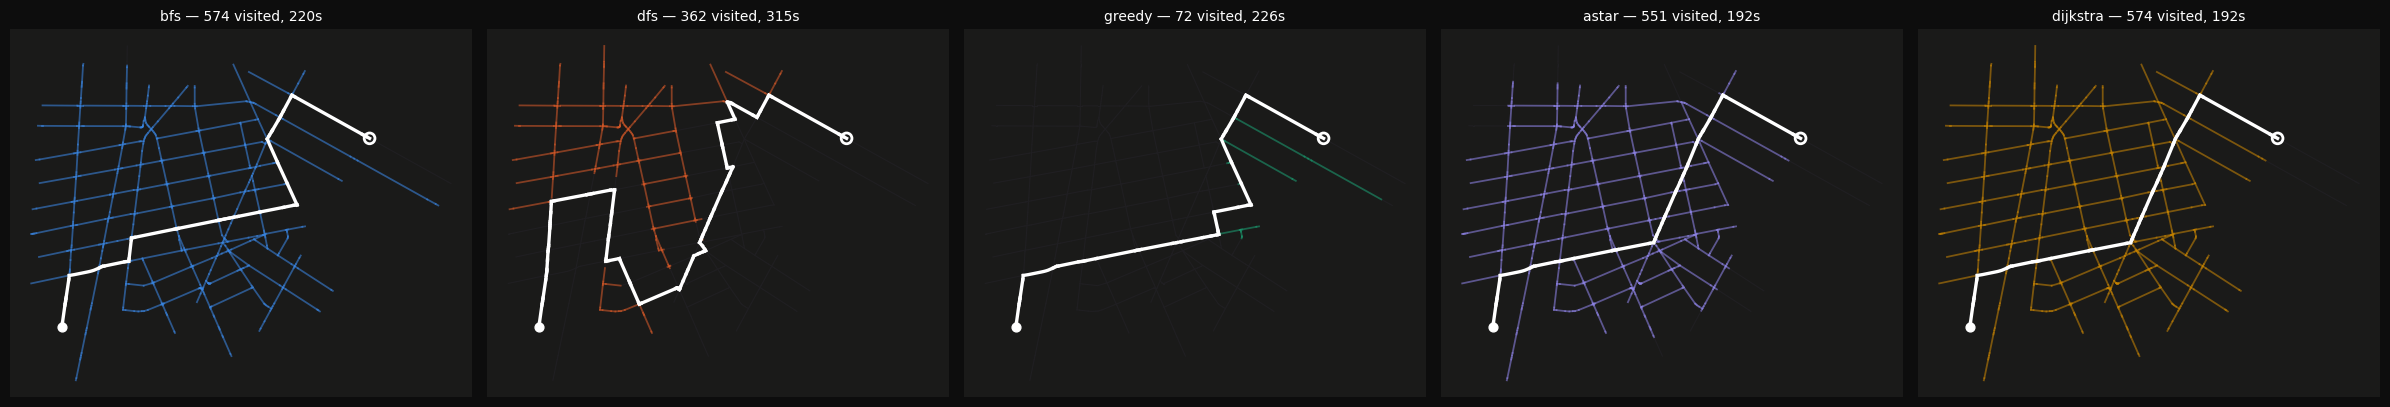

In [5]:
# Equirectangular projection, longitude corrected by cos(latitude) so the
# real street angles render correctly — same approach as the web version's
# canvas projection.
min_lat, max_lat = graph_data["bounds"]["minLat"], graph_data["bounds"]["maxLat"]
min_lon, max_lon = graph_data["bounds"]["minLon"], graph_data["bounds"]["maxLon"]
lon_scale = math.cos(math.radians((min_lat + max_lat) / 2))


def project(lat, lon):
    x = (lon - min_lon) * lon_scale
    y = lat - min_lat
    return x, y


def edge_path_used(u, v, order):
    """Was edge (u, v) the one used to reach v (or u) during this search?"""
    key = (u, v) if u < v else (v, u)
    return key


def plot_street_graph(ax, visited, path, color, title):
    for e in edges:
        xs, ys = zip(*(project(lat, lon) for lat, lon in e["points"]))
        ax.plot(xs, ys, color="#201f22", linewidth=0.8, zorder=1)

    visited_set = set(visited)
    for e in edges:
        if e["a"] in visited_set and e["b"] in visited_set:
            xs, ys = zip(*(project(lat, lon) for lat, lon in e["points"]))
            ax.plot(xs, ys, color=color, linewidth=1.3, alpha=0.55, zorder=2)

    if path:
        for u, v in zip(path, path[1:]):
            key = (u, v) if u < v else (v, u)
            e = edge_lookup[key]
            xs, ys = zip(*(project(lat, lon) for lat, lon in e["points"]))
            ax.plot(xs, ys, color="#ffffff", linewidth=2.4, zorder=3)

    sx, sy = project(*nodes[start])
    gx, gy = project(*nodes[goal])
    ax.scatter([sx], [sy], color="#ffffff", s=40, zorder=4)
    ax.scatter([gx], [gy], facecolors="none", edgecolors="#ffffff", linewidths=2, s=60, zorder=4)

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=10)


results = {
    "bfs": (bfs_visited, bfs_path),
    "dfs": (dfs_visited, dfs_path),
    "greedy": (greedy_visited, greedy_path),
    "astar": (astar_visited, astar_path),
    "dijkstra": (dijkstra_visited, dijkstra_path),
}

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
for ax, (label, (visited, path)) in zip(axes, results.items()):
    seconds, meters = path_stats(path)
    plot_street_graph(ax, visited, path, ALGO_COLORS[label], f"{label} — {len(visited)} visited, {seconds:.0f}s")
plt.tight_layout()
plt.show()

## Checking the story across start/goal pairs

One route isn't proof of anything. Across 20 random start/goal pairs on this same real street network: does DFS's path stay longer than BFS's hop-count path? Do A-star and Dijkstra always agree on the optimal travel time? Does A-star reliably visit fewer intersections than Dijkstra? Is Greedy's travel time ever actually worse than optimal?

In [6]:
rng = random.Random(7)
node_ids = list(range(len(nodes)))

dfs_ratios = []
astar_dijkstra_match = 0
astar_fewer_visited = 0
greedy_worse_or_equal = 0
trials = 0

for i in range(20):
    st, gl = rng.sample(node_ids, 2)
    bv, bp = bfs(st, gl)
    dv, dp = dfs(st, gl)
    if bp is None or dp is None:
        continue  # skip disconnected pairs, shouldn't happen on this extract but stay defensive
    trials += 1
    dfs_ratios.append(len(dp) / len(bp))

    gv, gp = greedy_best_first(st, gl)
    djv, djp = dijkstra(st, gl)
    av, ap = a_star(st, gl)

    dj_seconds, _ = path_stats(djp)
    a_seconds, _ = path_stats(ap)
    g_seconds, _ = path_stats(gp)

    if abs(dj_seconds - a_seconds) < 1e-6:
        astar_dijkstra_match += 1
    if len(av) <= len(djv):
        astar_fewer_visited += 1
    if g_seconds >= dj_seconds - 1e-6:
        greedy_worse_or_equal += 1

    print(f"pair {i:2d}: DFS/BFS path {len(dp)/len(bp):.2f}x | "
          f"dijkstra={dj_seconds:6.1f}s astar={a_seconds:6.1f}s greedy={g_seconds:6.1f}s | "
          f"dijkstra_visited={len(djv):3d} astar_visited={len(av):3d}")

print(f"\nmean DFS/BFS path ratio: {sum(dfs_ratios) / len(dfs_ratios):.2f}x")
print(f"A-star and Dijkstra agreed on optimal time: {astar_dijkstra_match}/{trials}")
print(f"A-star visited <= Dijkstra's intersection count: {astar_fewer_visited}/{trials}")
print(f"Greedy's time was >= the optimal time: {greedy_worse_or_equal}/{trials}")

pair  0: DFS/BFS path 3.94x | dijkstra=  69.6s astar=  69.6s greedy=  72.4s | dijkstra_visited=345 astar_visited=152
pair  1: DFS/BFS path 9.73x | dijkstra=  47.2s astar=  47.2s greedy=  62.1s | dijkstra_visited=212 astar_visited= 98
pair  2: DFS/BFS path 5.00x | dijkstra=  37.3s astar=  37.3s greedy=  37.3s | dijkstra_visited=122 astar_visited= 32
pair  3: DFS/BFS path 5.94x | dijkstra= 118.8s astar= 118.8s greedy= 121.6s | dijkstra_visited=560 astar_visited=458
pair  4: DFS/BFS path 1.90x | dijkstra=  86.3s astar=  86.3s greedy=  86.3s | dijkstra_visited=486 astar_visited=327
pair  5: DFS/BFS path 2.19x | dijkstra= 103.3s astar= 103.3s greedy= 118.9s | dijkstra_visited=435 astar_visited=214
pair  6: DFS/BFS path 1.00x | dijkstra=  48.4s astar=  48.4s greedy=  48.4s | dijkstra_visited=211 astar_visited= 92
pair  7: DFS/BFS path 8.57x | dijkstra=  93.9s astar=  93.9s greedy=  93.9s | dijkstra_visited=241 astar_visited=174
pair  8: DFS/BFS path 1.03x | dijkstra=  73.4s astar=  73.4s gre

## Takeaways

- All five algorithms are one shared skeleton — expand the highest-priority frontier node, relax its neighbors, repeat. BFS, DFS, Greedy, Dijkstra, and A-star differ only in what "highest-priority" means (arrival order, arrival order, heuristic, cost-so-far, or both).
- BFS's shortest-*hop-count* guarantee and Dijkstra's shortest-*travel-time* guarantee are different claims — on a real street network they can disagree about which path is "better," because BFS has no idea some streets are faster than others.
- A-star and Dijkstra always agree on the optimal travel time (the heuristic — straight-line distance divided by the network's fastest road speed — never overestimates the true remaining travel time). They differ only in how much of the map they had to look at to find it: A-star's heuristic steers it toward the goal, so it reliably visits fewer intersections than Dijkstra for the identical answer.
- Greedy is fast to write and often looks like it's "going the right way" on the map, but nothing stops it from charging down a slow residential block because it never looks at accumulated travel time — its route is never faster than optimal, and is frequently slower.